In [18934]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stats
import seaborn as sns

In [18935]:
# Load the file 'salary_survey'
df = pd.read_csv('Salary_survey.csv')

In [18936]:
# See the first 5 values, to get an idea of the dataset that I am deling with
df.head()

,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:","What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)","How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",...,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,...,5-7 years,5-7 years,Master's degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Non-binary,NaN,NaN,NaN,NaN,NaN,NaN
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,...,2 - 4 years,2 - 4 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN


In [18937]:
# The features have very long names and can be confusing, so I will rename them
df = df.rename(columns = {
    df.columns[0]:'check',
    df.columns[1]:'age',
    df.columns[2]:'industry',
    df.columns[3]:'job title',
    df.columns[4]:'job details',
    df.columns[5]:'annual salary',
    df.columns[6]:'additional compensation',
    df.columns[7]:'currency',
    df.columns[8]:'other currency',
    df.columns[9]:'context extra income',
    df.columns[10]:'country',
    df.columns[11]:'state in US',
    df.columns[12]:'city',
    df.columns[13]:'overall experience',
    df.columns[14]:'field experience',
    df.columns[15]:'education',
    df.columns[16]:'gender',
})

In [18938]:
# Looks more clean
df.head()

,check,age,industry,job title,job details,annual salary,additional compensation,currency,other currency,context extra income,...,overall experience,field experience,education,gender,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,...,5-7 years,5-7 years,Master's degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Non-binary,NaN,NaN,NaN,NaN,NaN,NaN
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,...,2 - 4 years,2 - 4 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN


In [18939]:
# See the last 5 rows
df.tail()

,check,age,industry,job title,job details,annual salary,additional compensation,currency,other currency,context extra income,...,overall experience,field experience,education,gender,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
28173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18940]:
# Getting the number of [rows,columns]
df.shape

(28178, 23)

In [18941]:
# Taking a look of a general information about the dataset(columns,type,null values,etc..)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28178 entries, 0 to 28177
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   check                    28085 non-null  object 
 1   age                      28085 non-null  object 
 2   industry                 28011 non-null  object 
 3   job title                28084 non-null  object 
 4   job details              7267 non-null   object 
 5   annual salary            28085 non-null  object 
 6   additional compensation  20780 non-null  float64
 7   currency                 28085 non-null  object 
 8   other currency           207 non-null    object 
 9   context extra income     3044 non-null   object 
 10  country                  28085 non-null  object 
 11  state in US              23059 non-null  object 
 12  city                     28003 non-null  object 
 13  overall experience       28085 non-null  object 
 14  field experience      

In [18942]:
# It is not useful yet, because the a lot of NaN values, and some features need to be converted to numeric features
df.describe()

,additional compensation,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
count,2.078000e+04,0.0,0.0,0.0,0.0,0.0,0.0
mean,1.815342e+04,NaN,NaN,NaN,NaN,NaN,NaN
std,8.337722e+05,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
50%,2.000000e+03,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN
max,1.200000e+08,NaN,NaN,NaN,NaN,NaN,NaN


In [18943]:
# [rows,columns] before drop the duplicated rows

df.shape

(28178, 23)

In [18944]:
# Checking the duplicated rows
duplicated_rows = df[df.duplicated()]
print(f'There are {duplicated_rows.shape} duplicated rows on this dataset')

There are (92, 23) duplicated rows on this dataset


In [18945]:
# Drop the duplicated rows
df= df.drop_duplicates()

In [18946]:
# [rows,columns] after drop the duplicated rows
df.shape

(28086, 23)

In [18947]:
# Drop useless columns
df = df.drop(['check','job details','context extra income','Unnamed: 17','Unnamed: 18','Unnamed: 19','Unnamed: 20','Unnamed: 21','Unnamed: 22'], axis=1)

In [18948]:
# There will be more data on this function after some changes
df.describe()

,additional compensation
count,2.078000e+04
mean,1.815342e+04
std,8.337722e+05
min,0.000000e+00
25%,0.000000e+00
50%,2.000000e+03
75%,1.000000e+04
max,1.200000e+08


In [18949]:
# Reset the index after some deleted rows
df.reset_index(drop = True)


df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28086 entries, 0 to 28085
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      28085 non-null  object 
 1   industry                 28011 non-null  object 
 2   job title                28084 non-null  object 
 3   annual salary            28085 non-null  object 
 4   additional compensation  20780 non-null  float64
 5   currency                 28085 non-null  object 
 6   other currency           207 non-null    object 
 7   country                  28085 non-null  object 
 8   state in US              23059 non-null  object 
 9   city                     28003 non-null  object 
 10  overall experience       28085 non-null  object 
 11  field experience         28085 non-null  object 
 12  education                27863 non-null  object 
 13  gender                   27914 non-null  object 
dtypes: float64(1), object(13)
m

In [18950]:
# Checking null values
df.isnull().sum()

age                            1
industry                      75
job title                      2
annual salary                  1
additional compensation     7306
currency                       1
other currency             27879
country                        1
state in US                 5027
city                          83
overall experience             1
field experience               1
education                    223
gender                       172
dtype: int64

In [18951]:
# There are a lot of null values that I can see It represents less than 1%, for this reason, I am going to check them.
# I will drop them

print('% of null values')
print(f'\nage: {1/28086*100}% \n\nindustry: {(75/28086*100)}% \n\njob title: {2/28086*100}% \n\nannual salary: {1/228086*100}% \n\ncurrency: {1/28086*100}% \n\ncountry: {1/28086*100}% \n\noverall experience: {1/28086*100}% \n\nfield experience: {1/28086*100}%\n\neducation: {223/28086*100}% \n\ngender: {172/28086*100}%')

df = df.dropna(subset = ['age', 'industry', 'job title', 'annual salary', 'currency', 'country', 'overall experience', 'field experience','education','gender'],axis=0)

% of null values

age: 0.0035604927721996724% 

industry: 0.26703695791497545% 

job title: 0.007120985544399345% 

annual salary: 0.00043843111808703736% 

currency: 0.0035604927721996724% 

country: 0.0035604927721996724% 

overall experience: 0.0035604927721996724% 

field experience: 0.0035604927721996724%

education: 0.793989888200527% 

gender: 0.6124047568183436%


In [18952]:
df.isnull().sum()

age                            0
industry                       0
job title                      0
annual salary                  0
additional compensation     7142
currency                       0
other currency             27464
country                        0
state in US                 4908
city                          81
overall experience             0
field experience               0
education                      0
gender                         0
dtype: int64

<Axes: xlabel='additional compensation'>

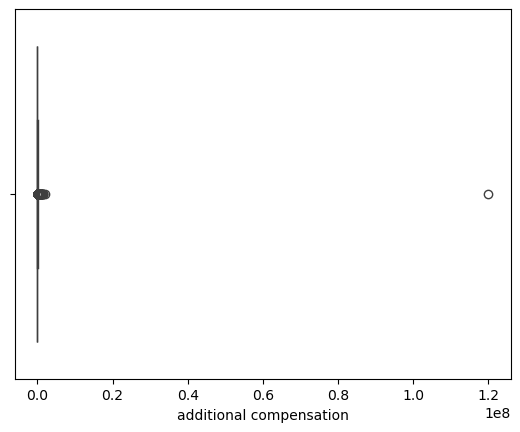

In [18953]:
# Checking if there is any outliers
sns.boxplot(x=df['additional compensation'])

In [18954]:
# 26% of the value in the additional compensation is null, so I will replace.
# There is outliers values in the dataset, for this reason, I am going to replace for median()
print(f'Additional compensation null values {7398/28178*100}%')

df.loc[:,'additional compensation'] = df['additional compensation'].fillna(df['additional compensation'].median())

df['additional compensation'].isnull().sum()

Additional compensation null values 26.254524806586698%


0

In [18955]:
# As I checked, 'annual salary' is object, so I need to remove the special characters
df['annual salary'] = df['annual salary'].astype(str)
df['annual salary'] = df['annual salary'].str.replace(',','')

# Converting to float
df['annual salary'] = df['annual salary'].astype(float)

<Axes: xlabel='annual salary'>

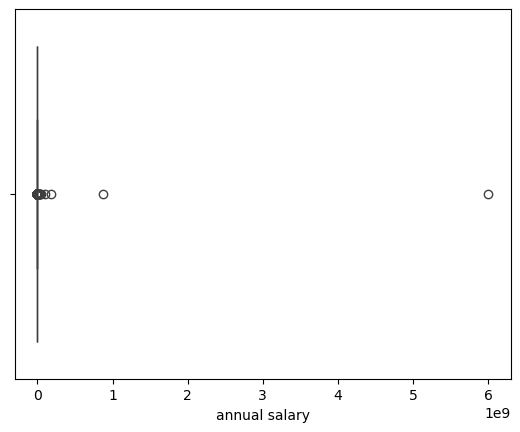

In [18956]:
# Now I can check properly the feature 'annual salary'
sns.boxplot(x=df['annual salary'])

<Axes: xlabel='overall experience'>

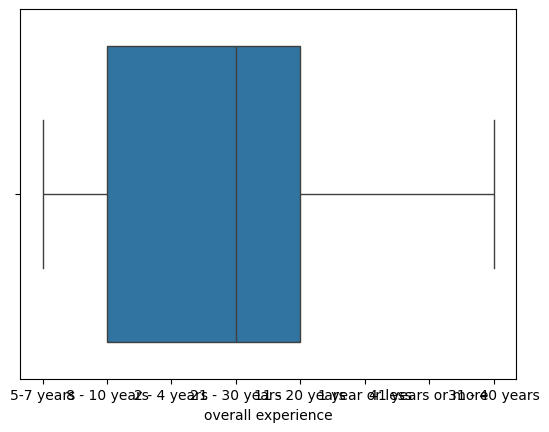

In [18957]:
sns.boxplot(x=df['overall experience'])

<Axes: xlabel='field experience'>

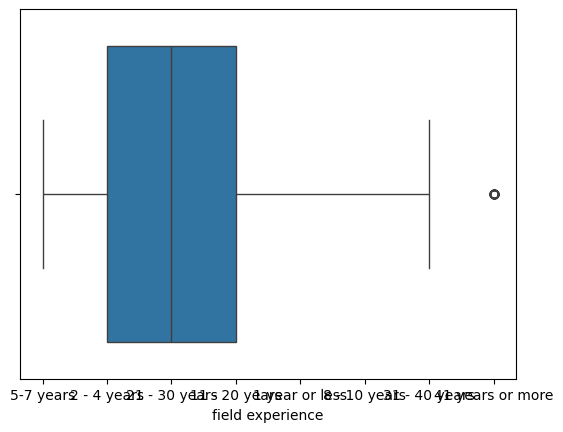

In [18958]:
sns.boxplot(x=df['field experience'])

In [18959]:
# The features 'overall experience' and 'field experience' should be numeric, but to convert them, I need to eliminate the strings. 
# In experience, there is a range of x-y years, I will take into account the lowest value of the range and fill the null values

# Get just the first two numbers
df['overall experience'] = df['overall experience'].str.slice(0,2)

#Removing '-', if there is any
df['overall experience'] = df['overall experience'].str.replace('-','')

# Excluding spaces
df['overall experience'] = df['overall experience'].str.strip()

# Convert to numeric column
df['overall experience'] = df['overall experience'].astype(float)

# Fill the null values with the mean, because there is an asymmetric distribution ,so I going to use median
df['overall experience'] = df['overall experience'].fillna(df['overall experience'].median())

#Convert float to int
df['overall experience'] = df['overall experience'].astype(int)


# The same logic to 'overall experience'
df['field experience'] = df['field experience'].str.slice(0,2)
df['field experience'] = df['field experience'].str.replace('-','')
df['field experience'] = df['field experience'].str.strip()
df['field experience'] = df['field experience'].astype(float)
df['field experience'] = df['field experience'].fillna(df['field experience'].median())
df['field experience'] = df['field experience'].astype(int)
df[['field experience','overall experience']].isnull().sum()

field experience      0
overall experience    0
dtype: int64

In [18960]:
# To handle with the feature 'Age', the idea is very similar to the experience, since there is string (years) and it is within a range. 
# Following the same criterion as the experience, I will take the smallest value in each range

# Making sure 'age' is string so, I can use these functions
df['age'] = df['age'].astype(str)

# Taking the first 2 characters
df['age'] = df['age'].str.slice(0,2)

# Now under 18 became un, so I going to replace, un=18
df['age'] = df['age'].replace('un',18)

df['age'] = df['age'].astype(float)

#There is an asymmetric distribution ,so I going to use median again
df['age'] = df['age'].fillna(df['age'].median())

# Convert to int, it is not possible to convert str to int, so float to fix the null values e after that, int
df['age'] = df['age'].astype(int)

print(f'Null values:{df['age'].isnull().sum()}')

Null values:0


<Axes: xlabel='age'>

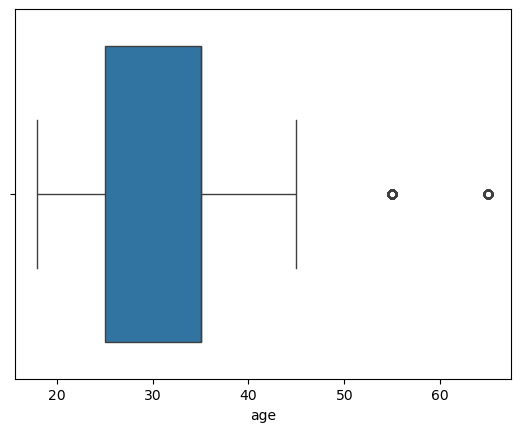

In [18961]:
# Looks better to get insights 
sns.boxplot(x=df['age'])

In [18962]:
# I am going to view again how the data looks like after few changes,
df.head()

,age,industry,job title,annual salary,additional compensation,currency,other currency,country,state in US,city,overall experience,field experience,education,gender
0,25,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,USD,NaN,United States,Massachusetts,Boston,5,5,Master's degree,Woman
1,25,Computing or Tech,Change & Internal Communications Manager,54600.0,4000.0,GBP,NaN,United Kingdom,NaN,Cambridge,8,5,College degree,Non-binary
2,25,"Accounting, Banking & Finance",Marketing Specialist,34000.0,2000.0,USD,NaN,US,Tennessee,Chattanooga,2,2,College degree,Woman
3,25,Nonprofits,Program Manager,62000.0,3000.0,USD,NaN,USA,Wisconsin,Milwaukee,8,5,College degree,Woman
4,25,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,USD,NaN,US,South Carolina,Greenville,8,5,College degree,Woman


In [18963]:
# Checking null values again
df.isnull().sum()

age                            0
industry                       0
job title                      0
annual salary                  0
additional compensation        0
currency                       0
other currency             27464
country                        0
state in US                 4908
city                          81
overall experience             0
field experience               0
education                      0
gender                         0
dtype: int64

In [18964]:
# Checking how much employees filled 'Other' in the 'currency' feature
qty_currency = (df['currency'] == 'Other').sum()
print(qty_currency)

155


In [18965]:
# Comparing columns where currency = Other
df[df['currency'] == 'Other'][['currency','other currency']].head(10)

,currency,other currency
434,Other,INR
603,Other,Peso Argentino
1311,Other,MYR
1840,Other,CHF
1924,Other,NOK
2054,Other,NOK
2473,Other,USD
2639,Other,BR$
2980,Other,SEK
3162,Other,Dkk


In [18966]:
df.shape

(27662, 14)

In [18967]:
# These 155 rows, less than 0,57% of the dataset distributed in several currencies, written in numerous different ways
155/27662*100

0.5603354782734437

In [18968]:
# Drop the currencies where they answered Other
df = df[df['currency'] != 'Other']

In [18969]:
# To avoid wasting too much time on a tiny sample compared to the total data set, and processing to convert the numerous currencies
# I will exclude the Other Currency column, even because the fact that the employees live in different countries, can distort the analysis
df = df.drop(columns= ['other currency'], axis=1)

In [18970]:
df.shape

(27507, 13)

In [18971]:
# Checking the values on the feature 'currency'
df['currency'].unique()

array(['USD', 'GBP', 'CAD', 'EUR', 'AUD/NZD', 'CHF', 'ZAR', 'SEK', 'HKD',
       'JPY'], dtype=object)

In [18972]:
# Checking the quantity of unique values
df['currency'].nunique()

10

In [18973]:
# All the values are ok
df['currency'].value_counts().head(10)

currency
USD        23071
CAD         1647
GBP         1563
EUR          619
AUD/NZD      495
CHF           37
SEK           35
JPY           22
ZAR           14
HKD            4
Name: count, dtype: int64

In [18974]:
# Checking null values
df.isnull().sum()

age                           0
industry                      0
job title                     0
annual salary                 0
additional compensation       0
currency                      0
country                       0
state in US                4766
city                         81
overall experience            0
field experience              0
education                     0
gender                        0
dtype: int64

In [18975]:
# As we can see, there are a lot of repeated countries and a lot of wrong information
# For this reason and the fact that this information is not useful,I will drop it
df['country'].value_counts().sort_values().head(20)

country
U. S                                                                      1
I work for a UAE-based organization, though I am personally in the US.    1
Jamaica                                                                   1
UK, but for globally fully remote company                                 1
California                                                                1
europe                                                                    1
Northern Ireland, United Kingdom                                          1
Isle of Man                                                               1
Wales (UK)                                                                1
uS                                                                        1
united states of america                                                  1
Y                                                                         1
From New Zealand but on projects across APAC                              1
Aust

In [18976]:
# So, If 'Country' is not useful, 'City' and 'State in US' is the same situation
# % of null values in 'State in US', more than 25%, another reason to drop this columun
5026/20084*100

25.024895439155546

In [18977]:
# Checking the null values in 'city'.I will drop it, because it is just 81 null values, less than 0,29% of null values
81/28084*100

0.2884204529269335

In [18978]:
# I could fill these values using .mode(),bvut these features are useless for me, so I will drop 'City' and 'State in US'
df = df.drop(columns= ['city','state in US'])

In [18979]:
df.isnull().sum()

age                        0
industry                   0
job title                  0
annual salary              0
additional compensation    0
currency                   0
country                    0
overall experience         0
field experience           0
education                  0
gender                     0
dtype: int64

In [18980]:
# Now that currencies are standardized, to compare in the future and look for correlations, I need to compare them equally. 
# I will use the euro currency as the standard.

# Creating a dictionary with the price of each currency
conversion_price = {
    'USD': 0.858,
    'CAD': 0.615,
    'GBP': 1.139,
    'EUR': 1.162,
    'AUD/NZD': 0.565,
    'CHF': 1.081,
    'SEK': 0.0915,
    'JPY': 0.0056,
    'ZAR': 0.050,
    'CNY': 0.120,
    'HKD': 0.110
}

# Getting the price of conversion
df['euro conversion'] = df['currency'].map(convert_price)

# Multipling the salary for the conversion price
df['euro salary'] = df['annual salary'] * df['euro conversion']

# I can aplly the same logic for the feature 'additional compensation'

# Multipling the salary for the conversion price
df['euro additional compensation'] = df['additional compensation'] * df['euro conversion']

df.head()

,age,industry,job title,annual salary,additional compensation,currency,country,overall experience,field experience,education,gender,euro conversion,euro salary,euro additional compensation
0,25,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,USD,United States,5,5,Master's degree,Woman,0.858,47190.0,0.0
1,25,Computing or Tech,Change & Internal Communications Manager,54600.0,4000.0,GBP,United Kingdom,8,5,College degree,Non-binary,1.139,62189.4,4556.0
2,25,"Accounting, Banking & Finance",Marketing Specialist,34000.0,2000.0,USD,US,2,2,College degree,Woman,0.858,29172.0,1716.0
3,25,Nonprofits,Program Manager,62000.0,3000.0,USD,USA,8,5,College degree,Woman,0.858,53196.0,2574.0
4,25,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,USD,US,8,5,College degree,Woman,0.858,51480.0,6006.0


In [18981]:
# Organazing the columns
df = df[['age', 'industry', 'job title','annual salary', 'euro salary','additional compensation', 'euro additional compensation', 'currency', 
         'overall experience', 'field experience', 'education', 'gender']]

In [18982]:
# Checking how it looks like
df.head()

,age,industry,job title,annual salary,euro salary,additional compensation,euro additional compensation,currency,overall experience,field experience,education,gender
0,25,Education (Higher Education),Research and Instruction Librarian,55000.0,47190.0,0.0,0.0,USD,5,5,Master's degree,Woman
1,25,Computing or Tech,Change & Internal Communications Manager,54600.0,62189.4,4000.0,4556.0,GBP,8,5,College degree,Non-binary
2,25,"Accounting, Banking & Finance",Marketing Specialist,34000.0,29172.0,2000.0,1716.0,USD,2,2,College degree,Woman
3,25,Nonprofits,Program Manager,62000.0,53196.0,3000.0,2574.0,USD,8,5,College degree,Woman
4,25,"Accounting, Banking & Finance",Accounting Manager,60000.0,51480.0,7000.0,6006.0,USD,8,5,College degree,Woman


In [18983]:
# I already converted Annual salary for euro annual salary, so for this reason, I do not need anymore the columns 'annual salary', 'additional compensation' and 'currency'
df = df.drop(columns=['annual salary','additional compensation','currency'],axis=1)

# Handling with categorical data

In [18984]:
# Reseting index again
df = df.reset_index(drop=True)


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27507 entries, 0 to 27506
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           27507 non-null  int32  
 1   industry                      27507 non-null  object 
 2   job title                     27507 non-null  object 
 3   euro salary                   27507 non-null  float64
 4   euro additional compensation  27507 non-null  float64
 5   overall experience            27507 non-null  int32  
 6   field experience              27507 non-null  int32  
 7   education                     27507 non-null  object 
 8   gender                        27507 non-null  object 
dtypes: float64(2), int32(3), object(4)
memory usage: 1.6+ MB


In [18985]:
# Basically 2 values are equal, so I am going to replace them
df['gender'].unique()

array(['Woman', 'Non-binary', 'Man', 'Other or prefer not to answer',
       'Prefer not to answer'], dtype=object)

In [18986]:
# Replacing 2 very similar values
df['gender'] = df['gender'].replace(['Other or prefer not to answer','Prefer not to answer'],'Other')

In [18987]:
# Checking if it worked
df['gender'].unique()

array(['Woman', 'Non-binary', 'Man', 'Other'], dtype=object)

In [18988]:
# One hot encoder to replace categorial values from gender
# I Choose this encoder because on 'gender' features, there is not hierarchy so I will not have problems

from sklearn.preprocessing import OneHotEncoder

# Encoding 'gender'
onehot = OneHotEncoder(sparse_output=False)
gender_encoded = onehot.fit_transform(df[['gender']])

In [18989]:
print(gender_encoded)

[[0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]]


In [18990]:
# Confirming that I have a array
type(gender_encoded)

numpy.ndarray

In [18991]:
# Giving name to my columns
gender_encoded_cols = onehot.get_feature_names_out(['gender'])

In [18992]:
# Creating a new dataframe, now with some numeric column that before, was categorical
df_gender = pd.DataFrame(gender_encoded, columns = gender_encoded_cols)
df_gender

,gender_Man,gender_Non-binary,gender_Other,gender_Woman
0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0
...,...,...,...,...
27502,0.0,0.0,0.0,1.0
27503,0.0,0.0,0.0,1.0
27504,1.0,0.0,0.0,0.0
27505,1.0,0.0,0.0,0.0


In [18993]:
# Joining the columns
df = pd.concat([df.drop(columns=['gender']),df_gender],axis=1)
df

,age,industry,job title,euro salary,euro additional compensation,overall experience,field experience,education,gender_Man,gender_Non-binary,gender_Other,gender_Woman
0,25,Education (Higher Education),Research and Instruction Librarian,47190.00,0.0,5,5,Master's degree,0.0,0.0,0.0,1.0
1,25,Computing or Tech,Change & Internal Communications Manager,62189.40,4556.0,8,5,College degree,0.0,1.0,0.0,0.0
2,25,"Accounting, Banking & Finance",Marketing Specialist,29172.00,1716.0,2,2,College degree,0.0,0.0,0.0,1.0
3,25,Nonprofits,Program Manager,53196.00,2574.0,8,5,College degree,0.0,0.0,0.0,1.0
4,25,"Accounting, Banking & Finance",Accounting Manager,51480.00,6006.0,8,5,College degree,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
27502,45,"Accounting, Banking & Finance",Product Manager Lead,100386.00,6864.0,11,11,College degree,0.0,0.0,0.0,1.0
27503,45,Education (Primary/Secondary),Curriculum Writer,60060.00,0.0,21,21,Master's degree,0.0,0.0,0.0,1.0
27504,55,Government and Public Administration,Clerical Officer,33233.20,2324.0,21,1,"Professional degree (MD, JD, etc.)",1.0,0.0,0.0,0.0
27505,18,Computing or Tech,Software Engineering Co-Op,48185.28,0.0,1,1,College degree,1.0,0.0,0.0,0.0


In [18994]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27507 entries, 0 to 27506
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           27507 non-null  int32  
 1   industry                      27507 non-null  object 
 2   job title                     27507 non-null  object 
 3   euro salary                   27507 non-null  float64
 4   euro additional compensation  27507 non-null  float64
 5   overall experience            27507 non-null  int32  
 6   field experience              27507 non-null  int32  
 7   education                     27507 non-null  object 
 8   gender_Man                    27507 non-null  float64
 9   gender_Non-binary             27507 non-null  float64
 10  gender_Other                  27507 non-null  float64
 11  gender_Woman                  27507 non-null  float64
dtypes: float64(6), int32(3), object(3)
memory usage: 2.2+ MB


In [18995]:
# Transforming these columns to int, because the values are 1 or 2, that is not necessary use float
df[['gender_Man', 'gender_Non-binary', 'gender_Other', 'gender_Woman']] = df[['gender_Man', 'gender_Non-binary', 'gender_Other', 'gender_Woman']].astype(int)

In [18996]:
# There is an idea of ​​ordinality when we talk about different levels of education, therefore, in the 'education' feature, I will use the OrdinalEncoder.
from sklearn.preprocessing import OrdinalEncoder

In [18997]:
# Getting the unique values on this feature
df['education'].unique()

array(["Master's degree", 'College degree', 'PhD', 'Some college',
       'High School', 'Professional degree (MD, JD, etc.)'], dtype=object)

In [18998]:
# As I said about ordinal values, I need to respect it in different education levels
education_levels = ["PhD", "Professional degree (MD, JD, etc.)","Master's degree",'College degree',"Some college","High School"]

education_encoder = OrdinalEncoder(categories=[education_levels])
education_encoded = education_encoder.fit_transform(df[['education']])

# I cannot concatenate object of type, only Series and DataFrame objs are valid, so I will transform education_encoded in DataFrame

education_encoded = pd.DataFrame(education_encoded, columns=['education_encoded'])

In [18999]:
df.head()

,age,industry,job title,euro salary,euro additional compensation,overall experience,field experience,education,gender_Man,gender_Non-binary,gender_Other,gender_Woman
0,25,Education (Higher Education),Research and Instruction Librarian,47190.0,0.0,5,5,Master's degree,0,0,0,1
1,25,Computing or Tech,Change & Internal Communications Manager,62189.4,4556.0,8,5,College degree,0,1,0,0
2,25,"Accounting, Banking & Finance",Marketing Specialist,29172.0,1716.0,2,2,College degree,0,0,0,1
3,25,Nonprofits,Program Manager,53196.0,2574.0,8,5,College degree,0,0,0,1
4,25,"Accounting, Banking & Finance",Accounting Manager,51480.0,6006.0,8,5,College degree,0,0,0,1


In [19000]:
# Joining the 2 columns
df = pd.concat([df.drop(columns=['education']),education_encoded], axis=1)

df.head()

,age,industry,job title,euro salary,euro additional compensation,overall experience,field experience,gender_Man,gender_Non-binary,gender_Other,gender_Woman,education_encoded
0,25,Education (Higher Education),Research and Instruction Librarian,47190.0,0.0,5,5,0,0,0,1,2.0
1,25,Computing or Tech,Change & Internal Communications Manager,62189.4,4556.0,8,5,0,1,0,0,3.0
2,25,"Accounting, Banking & Finance",Marketing Specialist,29172.0,1716.0,2,2,0,0,0,1,3.0
3,25,Nonprofits,Program Manager,53196.0,2574.0,8,5,0,0,0,1,3.0
4,25,"Accounting, Banking & Finance",Accounting Manager,51480.0,6006.0,8,5,0,0,0,1,3.0


In [19001]:
# Transforming these columns to int, because the values are 1 or 2, that is not necessary use float
df[['education_encoded']] = df[['education_encoded']].astype(int)


In [19002]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27507 entries, 0 to 27506
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           27507 non-null  int32  
 1   industry                      27507 non-null  object 
 2   job title                     27507 non-null  object 
 3   euro salary                   27507 non-null  float64
 4   euro additional compensation  27507 non-null  float64
 5   overall experience            27507 non-null  int32  
 6   field experience              27507 non-null  int32  
 7   gender_Man                    27507 non-null  int32  
 8   gender_Non-binary             27507 non-null  int32  
 9   gender_Other                  27507 non-null  int32  
 10  gender_Woman                  27507 non-null  int32  
 11  education_encoded             27507 non-null  int32  
dtypes: float64(2), int32(8), object(2)
memory usage: 1.7+ MB


In [19003]:
import sklearn.preprocessing as preproc

# Number of unique values on 'Industry' feature
df['industry'].nunique()

1206

In [19004]:
# Checking unique values
df['industry'].unique()

array(['Education (Higher Education)', 'Computing or Tech',
       'Accounting, Banking & Finance', ..., 'Student ', 'Wine & Spirits',
       'Social networks'], dtype=object)

In [19005]:
# Creating the encoder
le = preproc.LabelEncoder()

# Transforming the values
df['industry'] = le.fit_transform(df['industry'])

# Checking if the values were replaced
df['industry'].unique()

array([ 309,  212,   21, ..., 1012, 1105,  983])

In [19006]:
# Number of different titles on this feature
df['job title'].nunique()

14130

In [19007]:
investigate_values = df['job title'].sort_values().value_counts()
investigate_values

job title
Software Engineer              280
Project Manager                224
Senior Software Engineer       193
Director                       193
Program Manager                151
                              ... 
Gameplay Programmer              1
Gameplay engineer                1
Games Specialist                 1
Games User Research Manager      1
yard control                     1
Name: count, Length: 14130, dtype: int64

In [19008]:
# There are many job titles with very low frequency, which doesn't add anything to our analysis; for this reason, I'm going to delete this column.
df = df.drop(columns=['job title'])

In [19009]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27507 entries, 0 to 27506
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           27507 non-null  int32  
 1   industry                      27507 non-null  int32  
 2   euro salary                   27507 non-null  float64
 3   euro additional compensation  27507 non-null  float64
 4   overall experience            27507 non-null  int32  
 5   field experience              27507 non-null  int32  
 6   gender_Man                    27507 non-null  int32  
 7   gender_Non-binary             27507 non-null  int32  
 8   gender_Other                  27507 non-null  int32  
 9   gender_Woman                  27507 non-null  int32  
 10  education_encoded             27507 non-null  int32  
dtypes: float64(2), int32(9)
memory usage: 1.4 MB


# Handling with outliers

<Axes: ylabel='euro salary'>

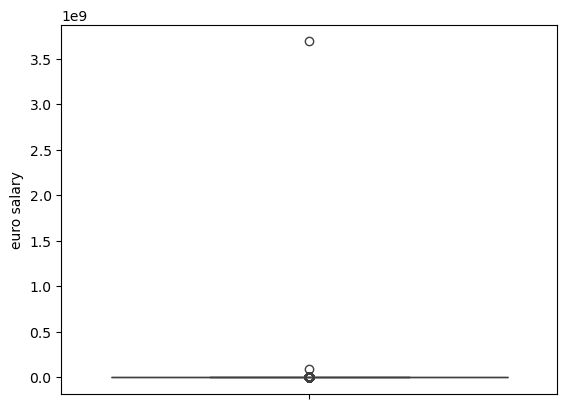

In [19010]:
sns.boxplot(df['euro salary'])

There are: 0 lower outliers
There are: 1146 upper outliers

Upper outlier values:[1.97340000e+05 1.60875000e+05 1.72329300e+05 ... 4.29000000e+06
 3.69004305e+09 1.71600000e+06] 
Mode outlier value: 171600.0

Maximum value: 3690043050.0 
Minimum value: 159588.0


<Axes: xlabel='euro salary'>

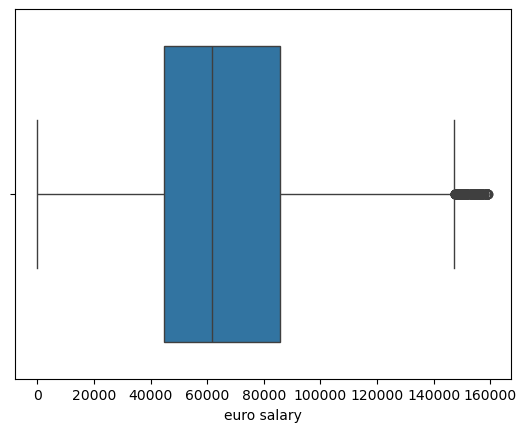

In [19011]:
# Too much outliers, and I do not want to drop them so, for this reason, using Winsorization, I am going to limit the outliers
# Lower Outliers I am going to use the minimum outlier, Upper outliers, I am going to use maximum outlier
Q1 = np.percentile(df['euro salary'],25)
Q3 = np.percentile(df['euro salary'],75)
IQR = Q3-Q1

lower_outlier = Q1 - 1.5 * IQR
upper_outlier = Q3 + 1.5 * IQR

low_outliers = df[df['euro salary'] < lower_outlier]
up_outliers = df[df['euro salary'] > upper_outlier]

print(f'There are: {(len(low_outliers))} lower outliers')
print(f'There are: {(len(up_outliers))} upper outliers')

print(f'\nUpper outlier values:{up_outliers["euro salary"].values} \nMode outlier value: {up_outliers["euro salary"].mode()[0]}')
print(f'\nMaximum value: {max(up_outliers["euro salary"])} \nMinimum value: {min(up_outliers["euro salary"]) }')

drop_values = up_outliers.index

# Drop the outliers on 'euro salary'
df = df.drop(drop_values, axis=0)

# Plotting with fewer outliers
sns.boxplot(x = df['euro salary'])

<Axes: xlabel='euro additional compensation'>

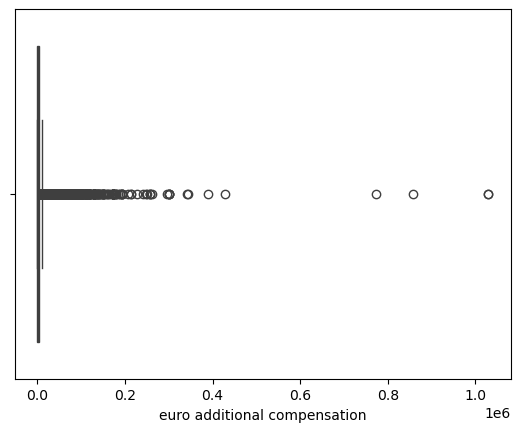

In [19012]:
# Drop the outliers on 'euro additional compensation'
sns.boxplot(x = df['euro additional compensation'])

There are: 0 lower outliers
There are: 3239 upper outliers

Upper outlier values:[12870. 42900. 17160. ... 12870. 12870. 12870.] 
Mode outlier value: 12870.0

Maximum value: 1029600.0 
Minimum value: 10734.999999999998


<Axes: xlabel='euro additional compensation'>

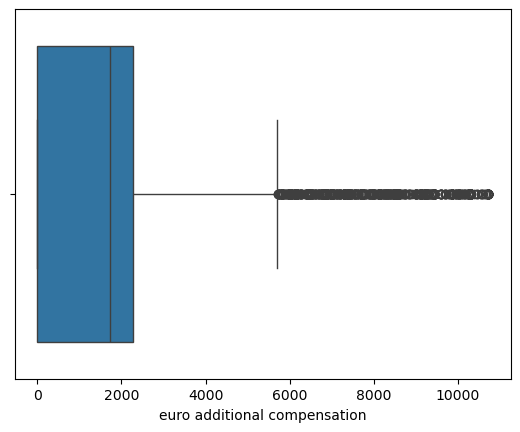

In [19013]:
# The situation is the same as the cell above. Even the logic is the same
Q1 = np.percentile(df['euro additional compensation'],25)
Q3 = np.percentile(df['euro additional compensation'],75)
IQR = Q3-Q1

lower_outliers = Q1 - 1.5 * IQR
upper_outliers = Q3 + 1.5 * IQR

low_outliers = df[df['euro additional compensation'] < lower_outliers]
up_outliers = df[df['euro additional compensation'] > upper_outliers]

print(f'There are: {(len(low_outliers))} lower outliers')
print(f'There are: {(len(up_outliers))} upper outliers')

print(f'\nUpper outlier values:{up_outliers["euro additional compensation"].values} \nMode outlier value: {up_outliers["euro additional compensation"].mode()[0]}')
print(f'\nMaximum value: {max(up_outliers["euro additional compensation"])} \nMinimum value: {min(up_outliers["euro additional compensation"]) }')

drop_values = up_outliers.index

# Drop the outliers
df = df.drop(drop_values,axis=0)

# Plotting with fewer outliers
sns.boxplot(x = df['euro additional compensation'])

<Axes: xlabel='age'>

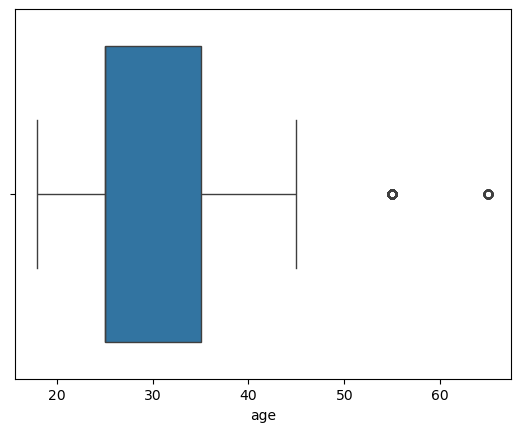

In [19014]:
sns.boxplot(x = df['age'])

There are: 0 lower outliers
There are: 872 upper outliers


<Axes: xlabel='age'>

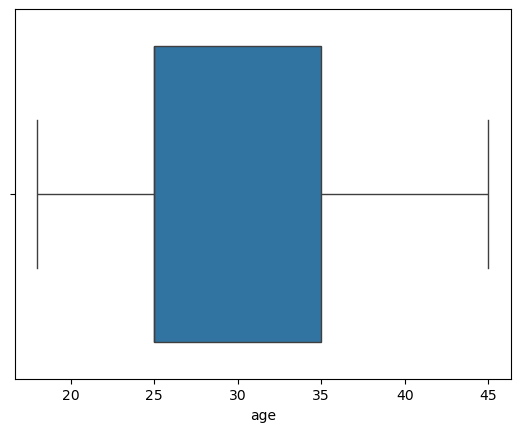

In [19015]:
# 'Age'
Q1 = np.percentile(df['age'],25)
Q3 = np.percentile(df['age'],75)
IQR = Q3-Q1

lower_outliers = Q1 - 1.5 * IQR
upper_outliers = Q3 + 1.5 * IQR

low_outliers = df[df['age'] < lower_outliers]
up_outliers = df[df['age'] > upper_outliers]

print(f'There are: {(len(low_outliers))} lower outliers')
print(f'There are: {(len(up_outliers))} upper outliers')

drop_values = up_outliers.index

# Drop the outliers on 'age'
df = df.drop(drop_values, axis=0)

# Plottling without outliers
sns.boxplot(x = df['age'])

<Axes: xlabel='overall experience'>

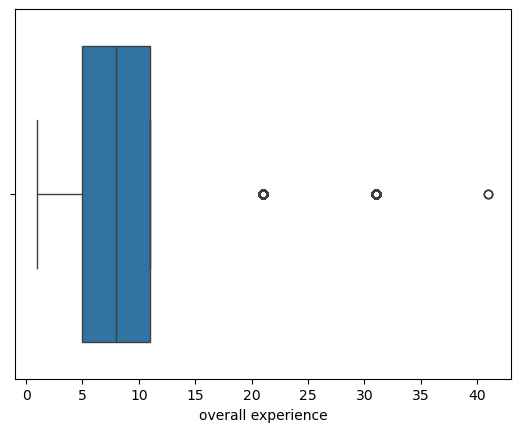

In [19016]:
sns.boxplot(x=df['overall experience'])

There are: 0 lower outliers
There are: 2803 upper outliers


<Axes: xlabel='overall experience'>

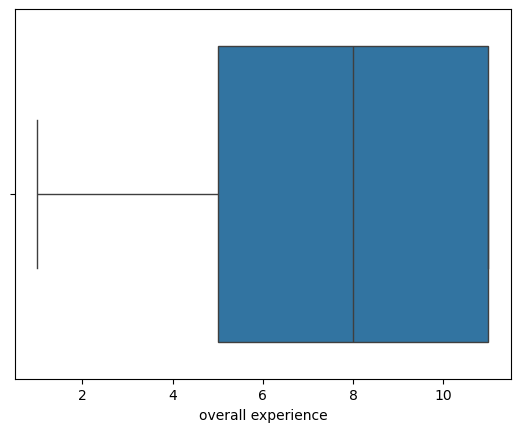

In [19017]:
# 'overall experience'
Q1 = np.percentile(df['overall experience'],25)
Q3 = np.percentile(df['overall experience'],75)
IQR = Q3-Q1

lower_outlier = Q1 - 1.5 * IQR
upper_outlier = Q3 + 1.5 * IQR

low_outliers = df[df['overall experience'] < lower_outlier]
up_outliers = df[df['overall experience'] > upper_outlier]

print(f'There are: {(len(low_outliers))} lower outliers')
print(f'There are: {(len(up_outliers))} upper outliers')

drop_values = up_outliers.index

# Drop the outliers on 'overall experience'
df = df.drop(drop_values,axis=0)

# Plotting without outliers
sns.boxplot(x=df['overall experience'])

<Axes: xlabel='field experience'>

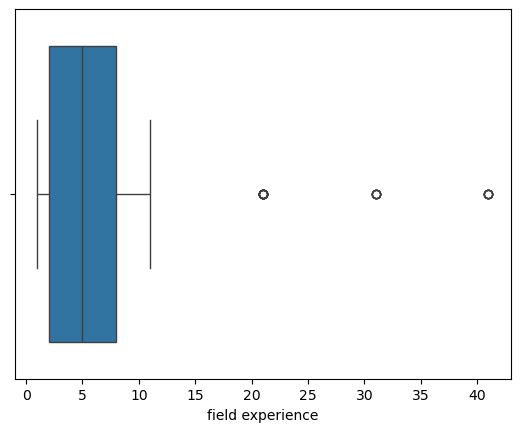

In [19018]:
sns.boxplot(x=df['field experience'])

There are: 0 lower outliers
There are: 21 upper outliers


<Axes: xlabel='field experience'>

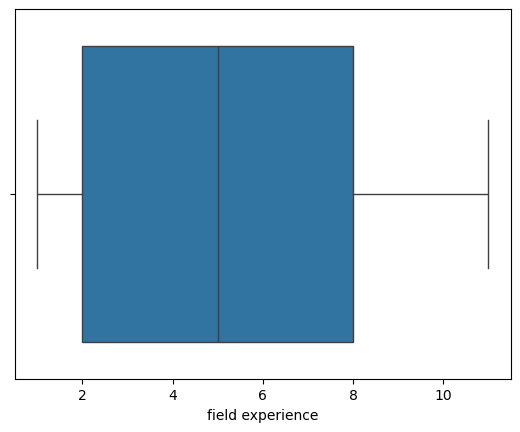

In [19019]:
# 'field experience'
Q1 = np.percentile(df['field experience'],25)
Q3 = np.percentile(df['field experience'],75)
IQR = Q3-Q1

lower_outlier = Q1 - 1.5 * IQR
upper_outlier = Q3 + 1.5 * IQR

low_outliers = df[df['field experience'] < lower_outlier]
up_outliers = df[df['field experience'] > upper_outlier]

print(f'There are: {(len(low_outliers))} lower outliers')
print(f'There are: {(len(up_outliers))} upper outliers')

drop_values = up_outliers.index

# Drop the outliers on 'field experience'
df = df.drop(drop_values,axis=0)

# Plotting without outliers
sns.boxplot(x=df['field experience'])

In [19020]:
# Now this method is much more informative than before
df.describe().round()

,age,industry,euro salary,euro additional compensation,overall experience,field experience,gender_Man,gender_Non-binary,gender_Other,gender_Woman,education_encoded
count,19426.0,19426.0,19426.0,19426.0,19426.0,19426.0,19426.0,19426.0,19426.0,19426.0,19426.0
mean,29.0,457.0,62104.0,1993.0,8.0,6.0,0.0,0.0,0.0,1.0,3.0
std,6.0,263.0,27154.0,2433.0,3.0,3.0,0.0,0.0,0.0,0.0,1.0
min,18.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
25%,25.0,212.0,42900.0,0.0,5.0,2.0,0.0,0.0,0.0,1.0,2.0
50%,25.0,464.0,57108.0,1716.0,8.0,5.0,0.0,0.0,0.0,1.0,3.0
75%,35.0,638.0,77220.0,2278.0,11.0,8.0,0.0,0.0,0.0,1.0,3.0
max,45.0,1205.0,158730.0,10725.0,11.0,11.0,1.0,1.0,1.0,1.0,5.0


In [19021]:
# Plotting some features to get more knowlegde about the dataset

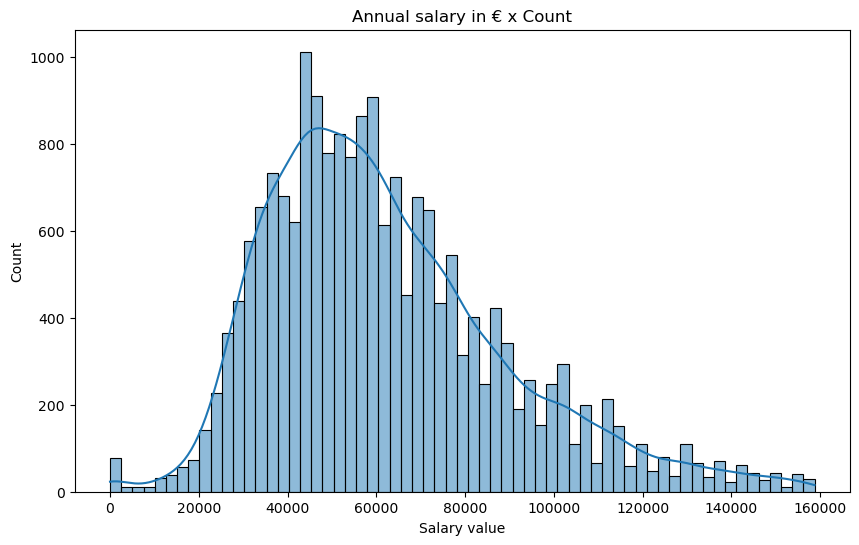

In [19022]:
# euro salary
plt.figure(figsize=(10,6))
sns.histplot(df, x = df['euro salary'], kde=True)
plt.title('Annual salary in € x Count')
plt.xlabel('Salary value')
plt.ylabel('Count')
plt.show()

#Asymmetrical graph, most part of them earn around 40k,right tail which suggests a positive asymmetry

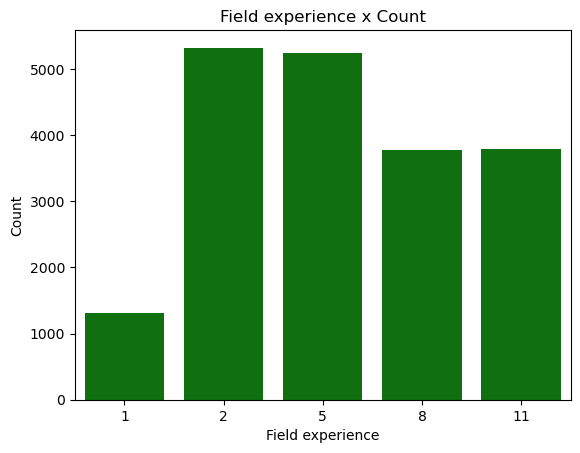

In [19023]:
# field experience
sns.countplot(df, x='field experience', color='g',)
plt.title('Field experience x Count')
plt.xlabel('Field experience')
plt.ylabel('Count')
plt.show()

#The data was grouped, so it's not possible to notice asymmetry or anything like that. 
#The best option is to show an aggregate of the number of people that fit each of the values.

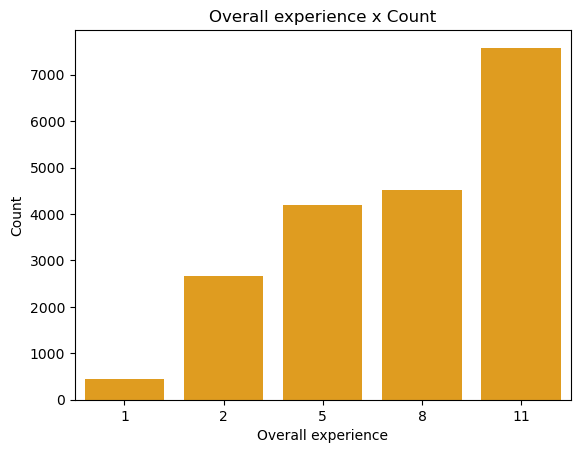

In [19024]:
# overall experience
sns.countplot(df, x='overall experience', color='orange',)
plt.title('Overall experience x Count')
plt.xlabel('Overall experience')
plt.ylabel('Count')
plt.show()

# The same idea as the graph above; both are talking about experience and have the same structure of grouped data, only the values ​​change.

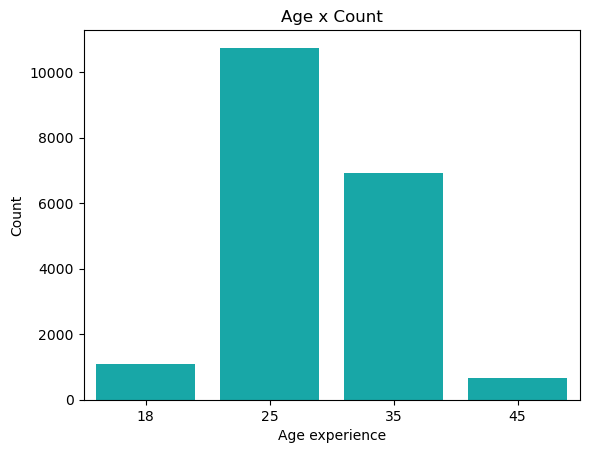

In [19025]:
# age
sns.countplot(df, x='age', color='c',)
plt.title('Age x Count')
plt.xlabel('Age experience')
plt.ylabel('Count')
plt.show()

# This graph have the same structure of grouped data, but in this case, we can see that around 17.000 employees are betweeen 25-35.

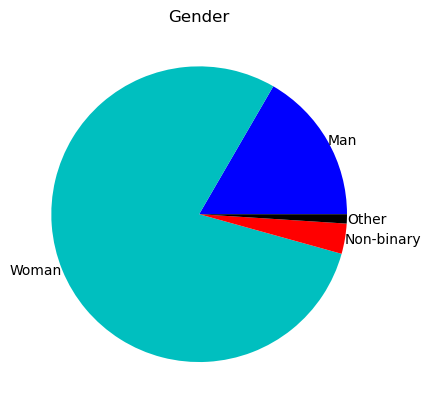

In [19026]:
#gender
labels = ['Man','Woman','Non-binary','Other']
colors = ['blue','c','red','black']
y = df[['gender_Man','gender_Woman','gender_Non-binary','gender_Other']].sum()
plt.pie(y,labels=labels, colors=colors, labeldistance= 1)
plt.title('Gender')
plt.show()

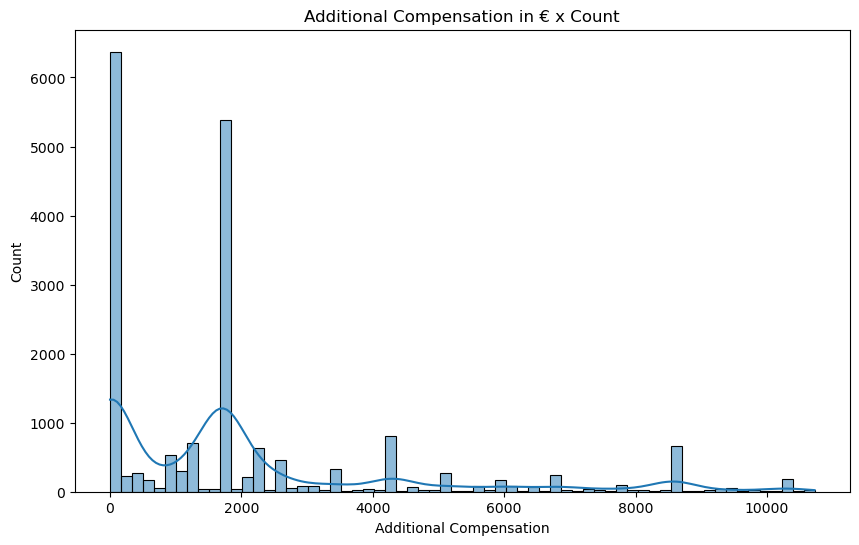

In [19027]:
# euro additional compensation
plt.figure(figsize=(10,6))
sns.histplot(df, x = df['euro additional compensation'], kde=True)
plt.title('Additional Compensation in € x Count')
plt.xlabel('Additional Compensation')
plt.ylabel('Count')
plt.show()

# Most part of them earn less than 2000€

In [19028]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19426 entries, 0 to 27505
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           19426 non-null  int32  
 1   industry                      19426 non-null  int32  
 2   euro salary                   19426 non-null  float64
 3   euro additional compensation  19426 non-null  float64
 4   overall experience            19426 non-null  int32  
 5   field experience              19426 non-null  int32  
 6   gender_Man                    19426 non-null  int32  
 7   gender_Non-binary             19426 non-null  int32  
 8   gender_Other                  19426 non-null  int32  
 9   gender_Woman                  19426 non-null  int32  
 10  education_encoded             19426 non-null  int32  
dtypes: float64(2), int32(9)
memory usage: 1.1 MB


# Selected Features

In [19029]:
from sklearn.feature_selection import SelectKBest, chi2

#apply SelectKBest to extract top 5 best features
bestfeatures = SelectKBest(score_func=chi2, k=5)

# Being floar, this function does not work
df['euro salary'] = df['euro salary'].astype(int)
X = df.iloc[:, df.columns != df.columns[2]]
y = df.iloc[:,2]

fit = bestfeatures.fit(X,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

In [19030]:
feature_scores = pd.concat([dfcolumns,dfscores],axis=1)
feature_scores.columns = ['Specs','Score']
print(feature_scores.nlargest(5,'Score'))

                          Specs         Score
2  euro additional compensation  1.295567e+07
1                      industry  5.621402e+05
4              field experience  1.093179e+04
3            overall experience  6.918914e+03
0                           age  5.404798e+03


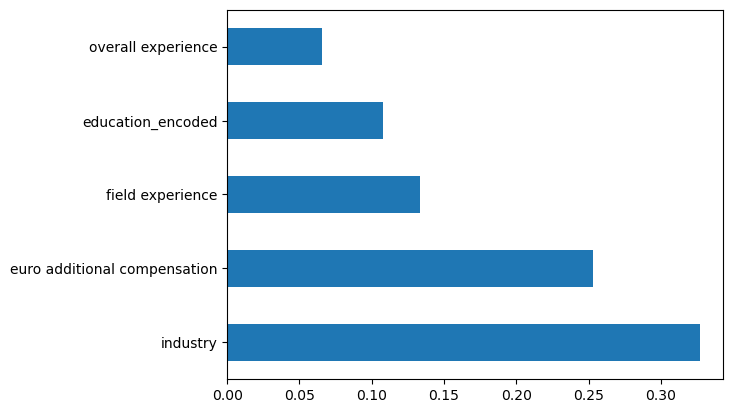

In [19031]:
# Plotting the columns and scores
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.show()

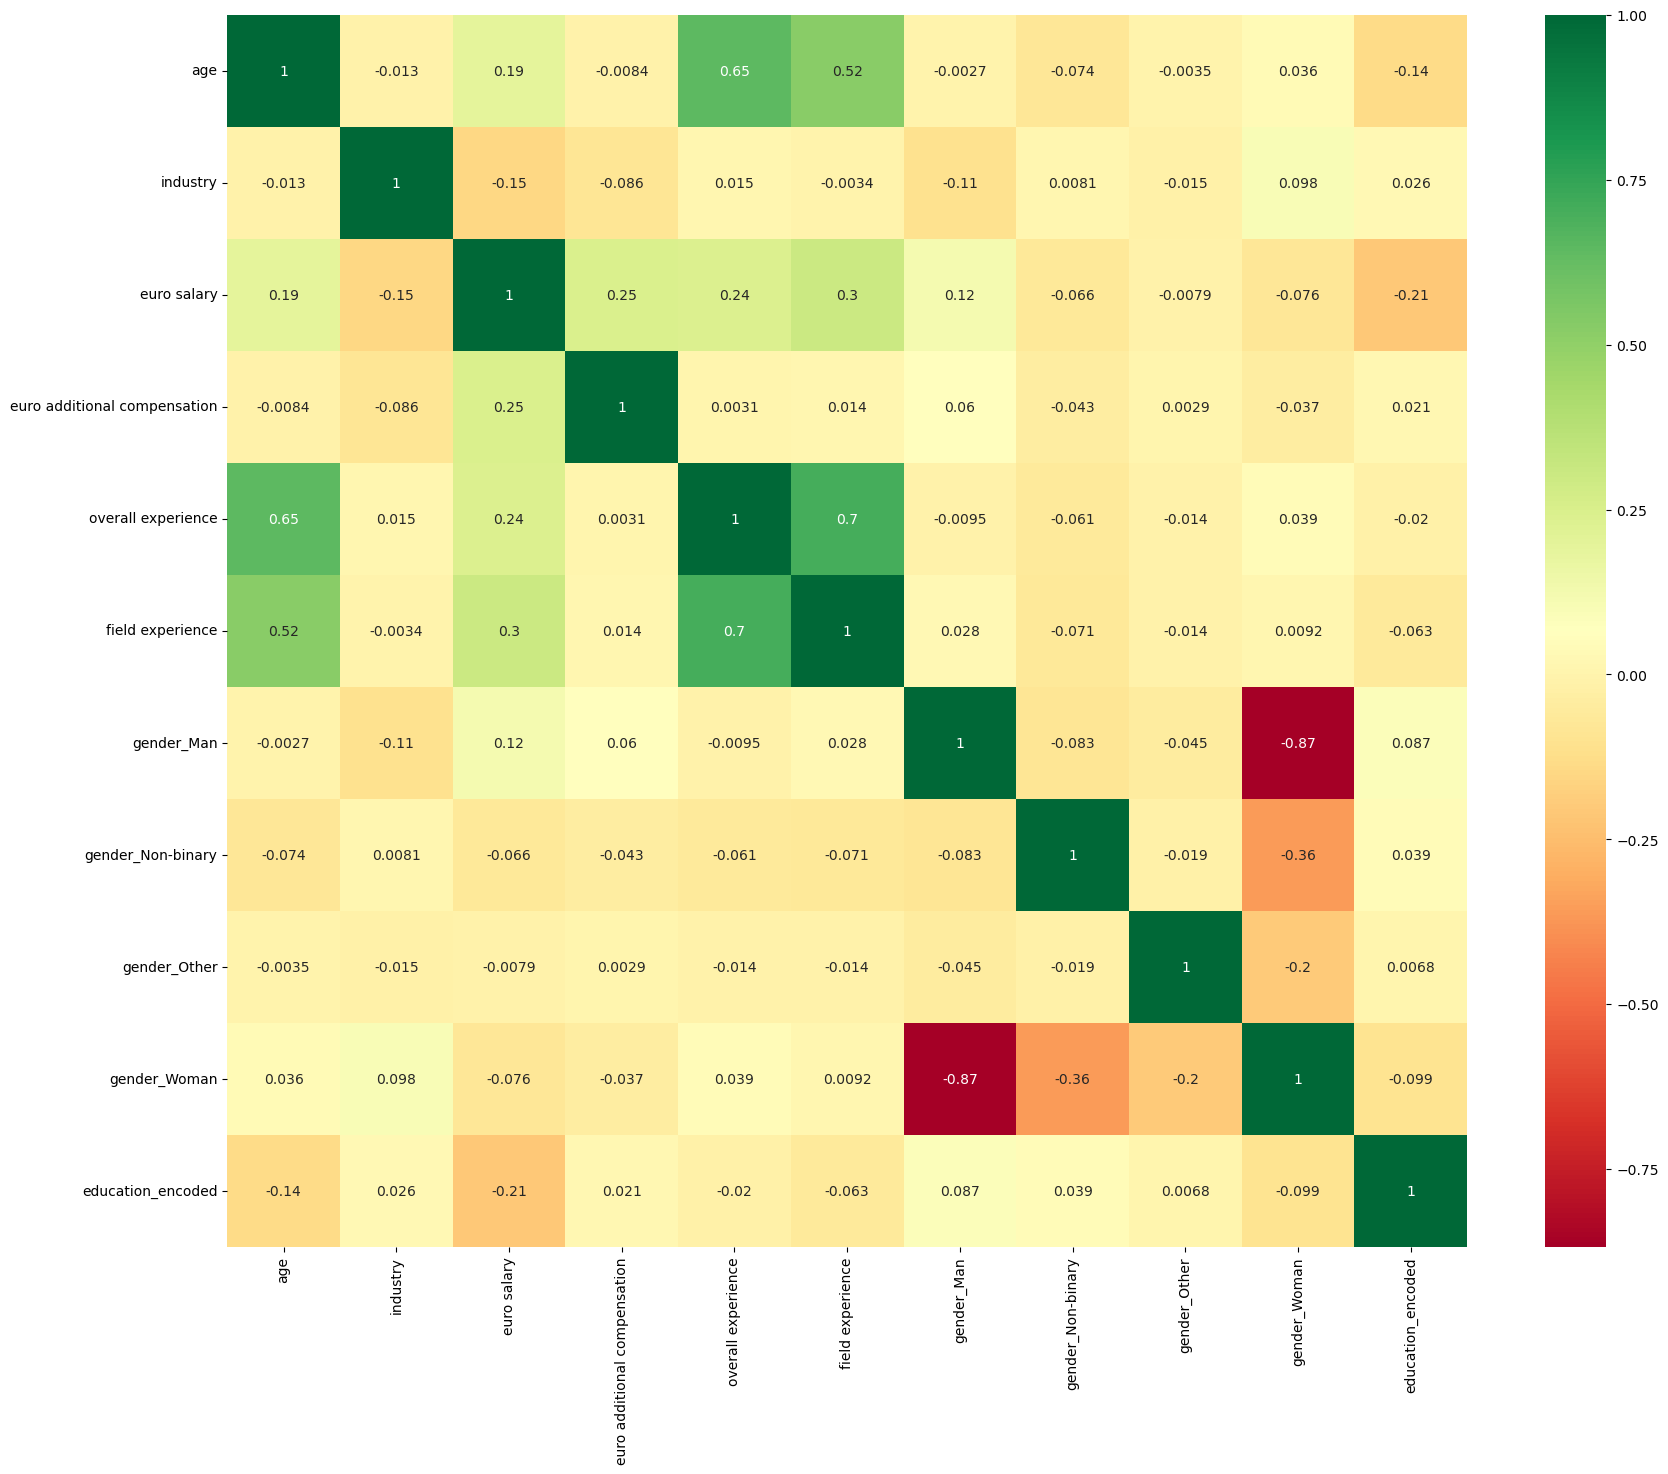

In [19032]:
# Plotting heatmap
corrmath = df.corr()
top_corre_features = corrmath.index
plt.figure(figsize=(20,16))

g= sns.heatmap(df[top_corre_features].corr(), annot=True, cmap='RdYlGn')